# Initialize

In [ ]:
import requests
import os
import pandas as pd
import numpy as np
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, classification_report
from sklearn.preprocessing import MultiLabelBinarizer

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import MobileBertConfig, MobileBertTokenizer, MobileBertForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Helper Function

In [ ]:
# Detailed emotions mapped to basic emotions
EMOTION_MAPPING = {
    'joy': ['joy', 'amusement', 'approval', 'excitement', 'gratitude', 'pride', 'optimism', 'relief', 'admiration'],
    'sadness': ['sadness', 'disappointment', 'grief', 'remorse'],
    'anger': ['anger', 'annoyance', 'disapproval', 'disgust'],
    'fear': ['fear', 'nervousness', 'embarrassment'],
    'love': ['love', 'caring', 'desire'],
    'surprise': ['surprise', 'realization', 'confusion', 'curiosity']
}

# Function to map emoticons to emotions
def map_emotions_to_emoticon(emotions):
    emotion_map = {
        'admiration': '😊',
        'amusement': '😄',
        'anger': '😠',
        'annoyance': '😒',
        'approval': '👍',
        'caring': '🤗',
        'confusion': '😕',
        'curiosity': '🤔',
        'desire': '😍',
        'disappointment': '😞',
        'disapproval': '👎',
        'disgust': '🤢',
        'embarrassment': '😳',
        'excitement': '😁',
        'fear': '😨',
        'gratitude': '🙏',
        'grief': '😢',
        'joy': '😃',
        'love': '❤️',
        'nervousness': '😰',
        'optimism': '🌟',
        'pride': '🦚',
        'realization': '💡',
        'relief': '😌',
        'remorse': '😔',
        'sadness': '😭',
        'surprise': '😲',
        'neutral': '😐'
    }

    emoticons = [emotion_map.get(emotion, '') for emotion in emotions]
    return ' '.join(filter(None, emoticons))

# Function to map detailed predictions to basic emotions
def map_to_basic_emotions(detailed_emotions):
    basic_emotions = set()
    for emotion in detailed_emotions:
        for basic, details in EMOTION_MAPPING.items():
            if emotion in details:
                basic_emotions.add(basic)
                break
    return list(basic_emotions)

# Bseline

In [ ]:
# Load datasets
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
val_df = pd.read_csv('data/val.csv')

print("Dataset sizes:")
print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
print(f"Validation: {val_df.shape}")

Dataset sizes:
Train: (4985, 30)
Test: (2230, 30)
Validation: (2178, 30)


In [ ]:
# Separate features and labels
emotion_columns = train_df.columns[2:]  # All columns except 'text' and 'id'

X_train = train_df['text']
y_train = train_df[emotion_columns]

X_test = test_df['text']
y_test = test_df[emotion_columns]

X_val = val_df['text']
y_val = val_df[emotion_columns]

# Feature extraction - using both Count and TF-IDF
# We'll compare both to see which performs better
count_vectorizer = CountVectorizer(stop_words='english', min_df=2, max_features=5000)
tfidf_vectorizer = TfidfVectorizer(stop_words='english', min_df=2, max_features=5000)

# Transform the text data
X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)
X_val_counts = count_vectorizer.transform(X_val)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
X_val_tfidf = tfidf_vectorizer.transform(X_val)

print(f"\nFeature dimensions:")
print(f"Count vectorizer features: {X_train_counts.shape[1]}")
print(f"TF-IDF vectorizer features: {X_train_tfidf.shape[1]}")

# Review class distribution
print("\nClass distribution in training set:")
for col in emotion_columns:
    pos_count = y_train[col].sum()
    total = len(y_train)
    print(f"{col}: {pos_count} counts ({100*pos_count/total:.2f}%)")


Feature dimensions:
Count vectorizer features: 3162
TF-IDF vectorizer features: 3162

Class distribution in training set:
admiration: 411 counts (8.24%)
amusement: 290 counts (5.82%)
anger: 290 counts (5.82%)
annoyance: 322 counts (6.46%)
approval: 372 counts (7.46%)
caring: 254 counts (5.10%)
confusion: 241 counts (4.83%)
curiosity: 296 counts (5.94%)
desire: 221 counts (4.43%)
disappointment: 317 counts (6.36%)
disapproval: 290 counts (5.82%)
disgust: 257 counts (5.16%)
embarrassment: 228 counts (4.57%)
excitement: 255 counts (5.12%)
fear: 266 counts (5.34%)
gratitude: 340 counts (6.82%)
grief: 143 counts (2.87%)
joy: 317 counts (6.36%)
love: 286 counts (5.74%)
nervousness: 248 counts (4.97%)
optimism: 328 counts (6.58%)
pride: 201 counts (4.03%)
realization: 295 counts (5.92%)
relief: 194 counts (3.89%)
remorse: 230 counts (4.61%)
sadness: 334 counts (6.70%)
surprise: 233 counts (4.67%)
neutral: 180 counts (3.61%)


In [ ]:
# Train Naive Bayes baseline models
nb_count = MultiOutputClassifier(MultinomialNB(alpha=0.1))
nb_count.fit(X_train_counts, y_train)

nb_tfidf = MultiOutputClassifier(MultinomialNB(alpha=0.1))
nb_tfidf.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_count_test = nb_count.predict(X_test_counts)
y_pred_tfidf_test = nb_tfidf.predict(X_test_tfidf)

y_pred_count_val = nb_count.predict(X_val_counts)
y_pred_tfidf_val = nb_tfidf.predict(X_val_tfidf)

In [ ]:
def evaluate_model(y_true, y_pred, model_name, dataset_name, emotion_columns, reduced_emotions=False):

    y_true = y_true.values
    y_pred = np.array(y_pred)

    # Calculate metrics for full 28 emotions first
    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    accuracy = accuracy_score(y_true, y_pred)

    # Print full metrics
    print(f"\nPerformance Metrics for {model_name} on {dataset_name} dataset:")
    print(f"[All Emotions]")
    print(f"Micro Precision: {precision_micro:.4f}")
    print(f"Micro Recall: {recall_micro:.4f}")
    print(f"Micro F1 Score: {f1_micro:.4f}")
    print(f"Macro Precision: {precision_macro:.4f}")
    print(f"Macro Recall: {recall_macro:.4f}")
    print(f"Macro F1 Score: {f1_macro:.4f}")
    print(f"Accuracy (Exact Match): {accuracy:.4f}")

    # If reduced emotions requested
    if reduced_emotions:
        # Create inverse mapping for quick lookup
        inverse_mapping = {}
        for basic_emotion, detailed_emotions in EMOTION_MAPPING.items():
            for de in detailed_emotions:
                inverse_mapping[de] = basic_emotion

        # Convert to reduced emotion format
        mlb = MultiLabelBinarizer(classes=sorted(EMOTION_MAPPING.keys()))

        # Process true labels
        true_basic = []
        for i in range(len(y_true)):
            active = [inverse_mapping[emotion_columns[j]]
                     for j in np.where(y_true[i] == 1)[0]
                     if emotion_columns[j] in inverse_mapping]
            true_basic.append(list(set(active)))

        # Process predictions
        pred_basic = []
        for i in range(len(y_pred)):
            active = [inverse_mapping[emotion_columns[j]]
                     for j in np.where(y_pred[i] == 1)[0]
                     if emotion_columns[j] in inverse_mapping]
            pred_basic.append(list(set(active)))

        # Binarize for sklearn metrics
        basic_true = mlb.fit_transform(true_basic)
        basic_pred = mlb.transform(pred_basic)

        # Calculate reduced metrics (treat as multi-label)
        reduced_metrics = {
            'precision_micro': precision_score(basic_true, basic_pred, average='micro', zero_division=0),
            'recall_micro': recall_score(basic_true, basic_pred, average='micro', zero_division=0),
            'f1_micro': f1_score(basic_true, basic_pred, average='micro', zero_division=0),
            'precision_macro': precision_score(basic_true, basic_pred, average='macro', zero_division=0),
            'recall_macro': recall_score(basic_true, basic_pred, average='macro', zero_division=0),
            'f1_macro': f1_score(basic_true, basic_pred, average='macro', zero_division=0),
            'accuracy': accuracy_score(basic_true, basic_pred)
        }

        print(f"\n[Reduced Emotions]")
        print(f"Micro Precision: {reduced_metrics['precision_micro']:.4f}")
        print(f"Micro Recall: {reduced_metrics['recall_micro']:.4f}")
        print(f"Micro F1 Score: {reduced_metrics['f1_micro']:.4f}")
        print(f"Macro Precision: {reduced_metrics['precision_macro']:.4f}")
        print(f"Macro Recall: {reduced_metrics['recall_macro']:.4f}")
        print(f"Macro F1 Score: {reduced_metrics['f1_macro']:.4f}")
        print(f"Accuracy (Exact Match): {reduced_metrics['accuracy']:.4f}")

    return {
        'full_metrics': {
            'precision_micro': precision_micro,
            'recall_micro': recall_micro,
            'f1_micro': f1_micro,
            'precision_macro': precision_macro,
            'recall_macro': recall_macro,
            'f1_macro': f1_macro,
            'accuracy': accuracy
        },
        'reduced_metrics': reduced_metrics if reduced_emotions else None
    }

In [ ]:
# Evaluate both models on test set
# Full emotions set and reduced emotions set
count_metrics_test = evaluate_model(y_test, y_pred_count_test, "Naive Bayes with Count Vectorizer", "test", emotion_columns, reduced_emotions=True)

tfidf_metrics_test = evaluate_model(y_test, y_pred_tfidf_test, "Naive Bayes with TF-IDF Vectorizer", "test",emotion_columns,reduced_emotions=True)



Performance Metrics for Naive Bayes with Count Vectorizer on test dataset:
[All Emotions]
Micro Precision: 0.3346
Micro Recall: 0.1302
Micro F1 Score: 0.1875
Macro Precision: 0.2743
Macro Recall: 0.1198
Macro F1 Score: 0.1634
Accuracy (Exact Match): 0.0717

[Reduced Emotions]
Micro Precision: 0.5505
Micro Recall: 0.2229
Micro F1 Score: 0.3173
Macro Precision: 0.4904
Macro Recall: 0.1979
Macro F1 Score: 0.2808
Accuracy (Exact Match): 0.1937

Performance Metrics for Naive Bayes with TF-IDF Vectorizer on test dataset:
[All Emotions]
Micro Precision: 0.5455
Micro Recall: 0.0339
Micro F1 Score: 0.0638
Macro Precision: 0.4196
Macro Recall: 0.0304
Macro F1 Score: 0.0533
Accuracy (Exact Match): 0.0305

[Reduced Emotions]
Micro Precision: 0.7525
Micro Recall: 0.0539
Micro F1 Score: 0.1006
Macro Precision: 0.7376
Macro Recall: 0.0467
Macro F1 Score: 0.0869
Accuracy (Exact Match): 0.0870


In [ ]:
# Evaluate both models on validation set
count_metrics_val = evaluate_model(y_val, y_pred_count_val, "Naive Bayes with Count Vectorizer", "validation",emotion_columns, reduced_emotions=True)
tfidf_metrics_val = evaluate_model(y_val, y_pred_tfidf_val, "Naive Bayes with TF-IDF Vectorizer", "validation",emotion_columns, reduced_emotions=True)


Performance Metrics for Naive Bayes with Count Vectorizer on validation dataset:
[All Emotions]
Micro Precision: 0.3610
Micro Recall: 0.1260
Micro F1 Score: 0.1868
Macro Precision: 0.3148
Macro Recall: 0.1227
Macro F1 Score: 0.1714
Accuracy (Exact Match): 0.0762

[Reduced Emotions]
Micro Precision: 0.6019
Micro Recall: 0.2232
Micro F1 Score: 0.3257
Macro Precision: 0.5475
Macro Recall: 0.2061
Macro F1 Score: 0.2969
Accuracy (Exact Match): 0.1938

Performance Metrics for Naive Bayes with TF-IDF Vectorizer on validation dataset:
[All Emotions]
Micro Precision: 0.6378
Micro Recall: 0.0359
Micro F1 Score: 0.0680
Macro Precision: 0.4259
Macro Recall: 0.0347
Macro F1 Score: 0.0616
Accuracy (Exact Match): 0.0321

[Reduced Emotions]
Micro Precision: 0.7842
Micro Recall: 0.0526
Micro F1 Score: 0.0986
Macro Precision: 0.7010
Macro Recall: 0.0518
Macro F1 Score: 0.0947
Accuracy (Exact Match): 0.0895


In [1]:
# Function to plot comparison bar plots
def plot_comparison(metrics_dict, title):
    models = list(metrics_dict.keys())
    metrics = ['precision_micro', 'recall_micro', 'f1_micro',
               'precision_macro', 'recall_macro', 'f1_macro', 'accuracy']

    fig, ax = plt.subplots(figsize=(9, 3))

    x = np.arange(len(metrics))
    width = 0.35 / len(models)

    for i, model in enumerate(models):
        values = [metrics_dict[model][m] for m in metrics]
        position = x + (i - len(models)/2 + 0.5) * width
        ax.bar(position, values, width, label=model)

    ax.set_ylabel('Score')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
    ax.legend()

    plt.tight_layout()
    plt.show()

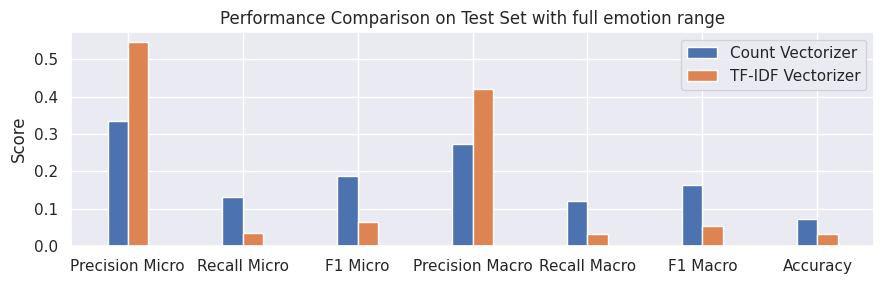

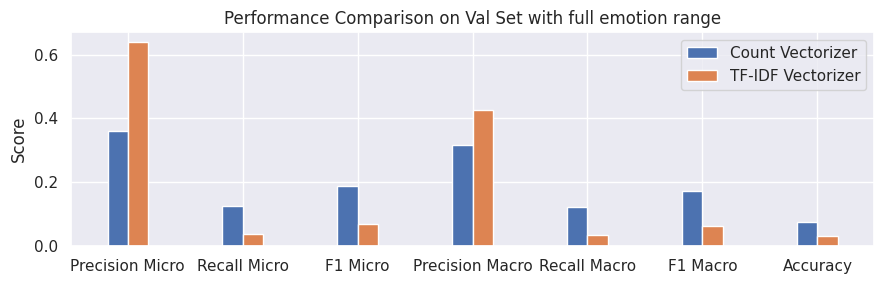

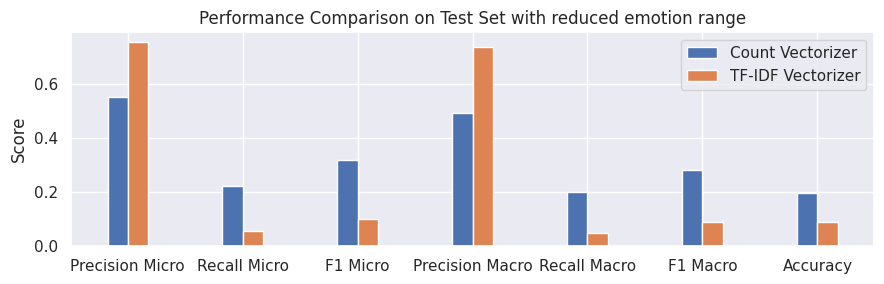

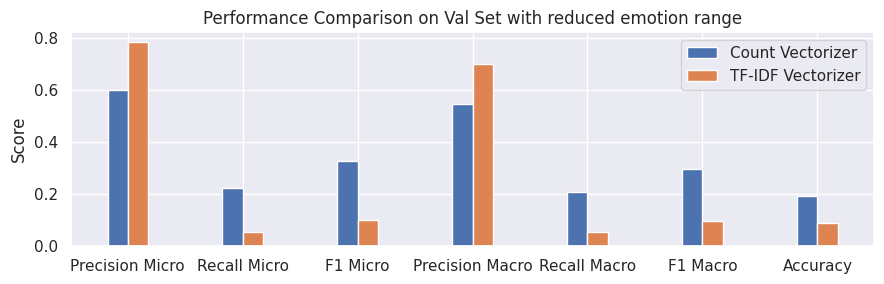

In [ ]:
# The following code plots the comparison graph between the different Naive-Bayes model
test_metrics = {
    'Count Vectorizer': count_metrics_test['full_metrics'],
    'TF-IDF Vectorizer': tfidf_metrics_test['full_metrics']
}
plot_comparison(test_metrics, 'Performance Comparison on Test Set with full emotion range')

val_metrics = {
    'Count Vectorizer': count_metrics_val['full_metrics'],
    'TF-IDF Vectorizer': tfidf_metrics_val['full_metrics']
}
plot_comparison(val_metrics, 'Performance Comparison on Val Set with full emotion range')

test_metrics = {
    'Count Vectorizer': count_metrics_test['reduced_metrics'],
    'TF-IDF Vectorizer': tfidf_metrics_test['reduced_metrics']
}
plot_comparison(test_metrics, 'Performance Comparison on Test Set with reduced emotion range')

val_metrics = {
    'Count Vectorizer': count_metrics_val['reduced_metrics'],
    'TF-IDF Vectorizer': tfidf_metrics_val['reduced_metrics']
}
plot_comparison(val_metrics, 'Performance Comparison on Val Set with reduced emotion range')

In [ ]:
# The following function predicts the emotion using Naive-bayes model
def predict_emotions(text, vectorizer, model, emotion_labels, true_labels=None):
    text_features = vectorizer.transform([text])
    predictions = model.predict(text_features)[0]
    predicted_emotions = [emotion_labels[i] for i, pred in enumerate(predictions) if pred == 1]

    # Get actual emotions if true_labels provided
    actual_emotions = None
    if true_labels is not None:
        actual_emotions = [emotion_labels[i] for i, val in enumerate(true_labels) if val == 1]

    return predicted_emotions, actual_emotions

# Get example texts with their true labels
example_indices = range(4, 8)  # Using range instead of direct indexing
example_texts = test_df.loc[example_indices, 'text'].values.tolist()
example_true_labels = test_df.loc[example_indices, emotion_columns].values

print("\nExample Predictions with Ground Truth:")
for i, text in enumerate(example_texts):
    if count_metrics_val['full_metrics']['f1_micro'] > tfidf_metrics_val['full_metrics']['f1_micro']:
        pred_emotions, true_emotions = predict_emotions(text, count_vectorizer, nb_count, emotion_columns, example_true_labels[i])
        model_name = "Count Vectorizer"
    else:
        pred_emotions, true_emotions = predict_emotions(text, tfidf_vectorizer, nb_tfidf, emotion_columns, example_true_labels[i])
        model_name = "TF-IDF Vectorizer"

    pred_emoticons = map_emotions_to_emoticon(pred_emotions)
    true_emoticons = map_emotions_to_emoticon(true_emotions) if true_emotions else None

    print(f"\nText: '{text}'")
    print(f"Model: {model_name}")
    print(f"Actual emotions: {true_emotions} | {true_emoticons}")
    print(f"Predicted emotions: {pred_emotions} | {pred_emoticons}")


Example Predictions with Ground Truth:

Text: 'This is awesome. But also r/dontdeadopeninside'
Model: Count Vectorizer
Actual emotions: ['admiration'] | 😊
Predicted emotions: ['admiration'] | 😊

Text: 'This is a very good point, which I hadn't thought of. Thanks dull!'
Model: Count Vectorizer
Actual emotions: ['admiration', 'gratitude'] | 😊 🙏
Predicted emotions: ['gratitude'] | 🙏

Text: 'Trier is low key an awful defender'
Model: Count Vectorizer
Actual emotions: ['admiration'] | 😊
Predicted emotions: ['fear'] | 😨

Text: 'Sapa is pretty good, but Takashi is by far the best quality sushi in Salt Lake.'
Model: Count Vectorizer
Actual emotions: ['admiration'] | 😊
Predicted emotions: ['admiration', 'joy'] | 😊 😃


# Main Model

In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Load datasets
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
val_df = pd.read_csv('data/val.csv')

# Extract emotion columns
emotion_columns = train_df.columns[2:]

print(f"Total samples - Train: {len(train_df)}, Test: {len(test_df)}, Validation: {len(val_df)}")
print(f"Number of emotion labels: {len(emotion_columns)}")

Total samples - Train: 4985, Test: 2230, Validation: 2178
Number of emotion labels: 28


In [ ]:
# Create dataset
class EmotionDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.FloatTensor(label)
        }

In [ ]:
# Load the tokenizer and configure the model
tokenizer = MobileBertTokenizer.from_pretrained('google/mobilebert-uncased')

# Configure for multi-label classification
config = MobileBertConfig.from_pretrained('google/mobilebert-uncased')
config.num_labels = len(emotion_columns)
config.problem_type = "multi_label_classification"

# Create model
model = MobileBertForSequenceClassification.from_pretrained(
    'google/mobilebert-uncased',
    config=config
)
# Move model to device
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/847 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/147M [00:00<?, ?B/s]

Some weights of MobileBertForSequenceClassification were not initialized from the model checkpoint at google/mobilebert-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


MobileBertForSequenceClassification(
  (mobilebert): MobileBertModel(
    (embeddings): MobileBertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 512)
      (token_type_embeddings): Embedding(2, 512)
      (embedding_transformation): Linear(in_features=384, out_features=512, bias=True)
      (LayerNorm): NoNorm()
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): MobileBertEncoder(
      (layer): ModuleList(
        (0-23): 24 x MobileBertLayer(
          (attention): MobileBertAttention(
            (self): MobileBertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=512, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): MobileBertSelfOutput(
              (dense): Linear(in_fe

In [ ]:
# Create datasets and dataloaders
train_texts = train_df['text'].tolist()
train_labels = train_df[emotion_columns].values.tolist()

val_texts = val_df['text'].tolist()
val_labels = val_df[emotion_columns].values.tolist()

test_texts = test_df['text'].tolist()
test_labels = test_df[emotion_columns].values.tolist()

train_dataset = EmotionDataset(train_texts, train_labels, tokenizer)
val_dataset = EmotionDataset(val_texts, val_labels, tokenizer)
test_dataset = EmotionDataset(test_texts, test_labels, tokenizer)

batch_size = 16
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)

In [ ]:
# Define training parameters
epochs = 5
optimizer = AdamW(model.parameters(), lr=2e-5)

# Calculate total training steps
total_steps = len(train_dataloader) * epochs

# Create learning rate scheduler
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0.1 * total_steps,
    num_training_steps=total_steps
)

In [ ]:
# Training function
def train_epoch(model, dataloader, optimizer, scheduler, device):
    model.train()
    total_loss = 0

    for batch in dataloader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

    avg_loss = total_loss / len(dataloader)
    return avg_loss

In [ ]:
# Evaluation function
def evaluate(model, dataloader, device):
    model.eval()
    predictions = []
    true_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits
            predictions.extend(torch.sigmoid(logits).cpu().numpy() > 0.5)
            true_labels.extend(labels.cpu().numpy())

    predictions = np.array(predictions).astype(int)
    true_labels = np.array(true_labels).astype(int)

    # Calculate metrics
    precision_micro = precision_score(true_labels, predictions, average='micro', zero_division=0)
    recall_micro = recall_score(true_labels, predictions, average='micro', zero_division=0)
    f1_micro = f1_score(true_labels, predictions, average='micro', zero_division=0)

    precision_macro = precision_score(true_labels, predictions, average='macro', zero_division=0)
    recall_macro = recall_score(true_labels, predictions, average='macro', zero_division=0)
    f1_macro = f1_score(true_labels, predictions, average='macro', zero_division=0)

    # Exact match accuracy (all labels must match)
    accuracy = accuracy_score(true_labels, predictions)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(true_labels, predictions, target_names=emotion_columns, zero_division=0))

    return {
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'accuracy': accuracy
    }

In [ ]:
def evaluate_reduced(model, dataloader, device):
    """BERT evaluation matching Naive Bayes' grouped emotion logic"""
    model.eval()
    basic_true, basic_pred = [], []

    for batch in dataloader:
        inputs = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)  # Explicit attention
        labels = batch['labels'].cpu().numpy()

        with torch.no_grad():
            outputs = model(inputs, attention_mask=attention_mask)
            probs = torch.sigmoid(outputs.logits).cpu().numpy()

            for i in range(len(labels)):
                # Convert true labels to basic groups
                true_emotions = [emotion_columns[j] for j in np.where(labels[i]==1)[0]]
                basic_true.append({g for g, es in EMOTION_MAPPING.items()
                                 if any(e in es for e in true_emotions)})

                pred_emotions = [emotion_columns[j] for j, p in enumerate(probs[i]) if p > 0.5]
                basic_pred.append({g for g, es in EMOTION_MAPPING.items()
                                 if any(e in es for e in pred_emotions)})

    mlb = MultiLabelBinarizer(classes=list(EMOTION_MAPPING.keys()))
    y_true = mlb.fit_transform(basic_true)
    y_pred = mlb.transform(basic_pred)

    # Calculate metrics
    precision_micro = precision_score(y_true, y_pred, average='micro', zero_division=0)
    recall_micro = recall_score(y_true, y_pred, average='micro', zero_division=0)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)

    precision_macro = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)

    # Exact match accuracy (all labels must match)
    accuracy = accuracy_score(y_true, y_pred,)

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred,
                                target_names=list(EMOTION_MAPPING.keys()),
                                zero_division=0))

    return {
        'precision_micro': precision_micro,
        'recall_micro': recall_micro,
        'f1_micro': f1_micro,
        'precision_macro': precision_macro,
        'recall_macro': recall_macro,
        'f1_macro': f1_macro,
        'accuracy': accuracy
    }

In [ ]:
# Training loop
training_stats = []
val_stats = []

for epoch in range(epochs):
    print(f"======== Epoch {epoch+1} / {epochs} ========")

    # Train
    avg_train_loss = train_epoch(model, train_dataloader, optimizer, scheduler, device)
    print(f"Average training loss: {avg_train_loss:.4f}")

    # Evaluate on validation set
    val_metrics = evaluate(model, val_dataloader, device)
    print(f"Validation metrics:")
    print(f"Micro Precision: {val_metrics['precision_micro']:.4f}")
    print(f"Micro Recall: {val_metrics['recall_micro']:.4f}")
    print(f"Micro F1: {val_metrics['f1_micro']:.4f}")
    print(f"Accuracy (Exact Match): {val_metrics['accuracy']:.4f}")

    training_stats.append(avg_train_loss)
    val_stats.append(val_metrics)

======== Epoch 1 / 5 ========
Average training loss: 354961.8722

Classification Report:
                precision    recall  f1-score   support

    admiration       0.43      0.02      0.03       186
     amusement       0.00      0.00      0.00       145
         anger       0.00      0.00      0.00       138
     annoyance       0.00      0.00      0.00       166
      approval       0.00      0.00      0.00       178
        caring       0.00      0.00      0.00       131
     confusion       0.00      0.00      0.00       120
     curiosity       0.00      0.00      0.00       147
        desire       0.00      0.00      0.00       116
disappointment       0.00      0.00      0.00       161
   disapproval       0.00      0.00      0.00       143
       disgust       0.00      0.00      0.00       138
 embarrassment       0.00      0.00      0.00        70
    excitement       0.00      0.00      0.00       133
          fear       0.00      0.00      0.00        97
     gratitude

In [ ]:
# Evaluate on test set
test_metrics = evaluate(model, test_dataloader, device)
test_metrics_re = evaluate_reduced(model, test_dataloader, device)


In [ ]:
print("\nTest Set Results for All Emotions:")
print(f"Micro Precision: {test_metrics['precision_micro']:.4f}")
print(f"Micro Recall: {test_metrics['recall_micro']:.4f}")
print(f"Micro F1: {test_metrics['f1_micro']:.4f}")
print(f"Macro Precision: {test_metrics['precision_macro']:.4f}")
print(f"Macro Recall: {test_metrics['recall_macro']:.4f}")
print(f"Macro F1: {test_metrics['f1_macro']:.4f}")
print(f"Accuracy (Exact Match): {test_metrics['accuracy']:.4f}")

print("\nTest Set Results for Emotion Group:")
print(f"Micro Precision: {test_metrics_re['precision_micro']:.4f}")
print(f"Micro Recall: {test_metrics_re['recall_micro']:.4f}")
print(f"Micro F1: {test_metrics_re['f1_micro']:.4f}")
print(f"Macro Precision: {test_metrics_re['precision_macro']:.4f}")
print(f"Macro Recall: {test_metrics_re['recall_macro']:.4f}")
print(f"Macro F1: {test_metrics_re['f1_macro']:.4f}")
print(f"Accuracy (Exact Match): {test_metrics_re['accuracy']:.4f}")


Test Set Results for All Emotions:
Micro Precision: 0.6087
Micro Recall: 0.1882
Micro F1: 0.2875
Macro Precision: 0.5387
Macro Recall: 0.1782
Macro F1: 0.2323
Accuracy (Exact Match): 0.1233

Test Set Results for Emotion Group:
Micro Precision: 0.8215
Micro Recall: 0.2847
Micro F1: 0.4229
Macro Precision: 0.7955
Macro Recall: 0.2597
Macro F1: 0.3814
Accuracy (Exact Match): 0.2794



Comparison with Naive Bayes baseline:
Metric			MobileBERT		Naive Bayes
Micro F1:		0.2875		0.1875
Micro Precision:	0.6087		0.3346
Micro Recall:		0.1882		0.1302
Accuracy:		0.1233		0.0717


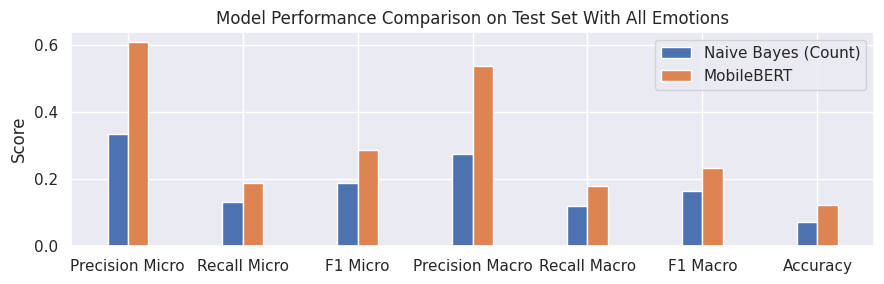


Comparison with Naive Bayes baseline:
Metric			MobileBERT		Naive Bayes
Micro F1:		0.4229		0.3173
Micro Precision:	0.8215		0.5505
Micro Recall:		0.2847		0.2229
Accuracy:		0.2794		0.1937


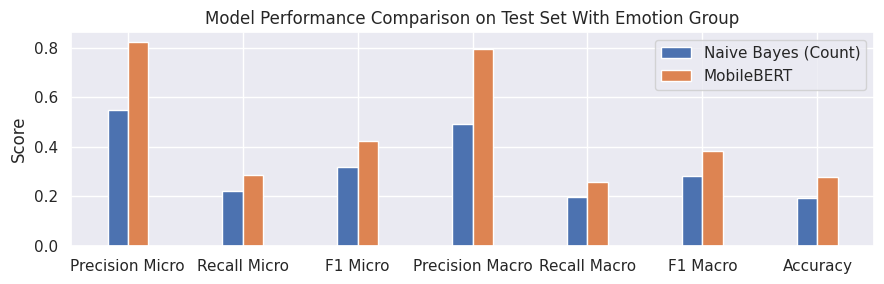

In [ ]:
# Compare with baseline Naive Bayes results
print("\nComparison with Naive Bayes baseline:")
print("Metric\t\t\tMobileBERT\t\tNaive Bayes")
print(f"Micro F1:\t\t{test_metrics['f1_micro']:.4f}\t\t{count_metrics_test['full_metrics']['f1_micro']:.4f}")
print(f"Micro Precision:\t{test_metrics['precision_micro']:.4f}\t\t{count_metrics_test['full_metrics']['precision_micro']:.4f}")
print(f"Micro Recall:\t\t{test_metrics['recall_micro']:.4f}\t\t{count_metrics_test['full_metrics']['recall_micro']:.4f}")
print(f"Accuracy:\t\t{test_metrics['accuracy']:.4f}\t\t{count_metrics_test['full_metrics']['accuracy']:.4f}")

# Extended performance comparison plot
comparison_metrics = {
    'Naive Bayes (Count)': count_metrics_test['full_metrics'],
    'MobileBERT': test_metrics
}
plot_comparison(comparison_metrics, 'Model Performance Comparison on Test Set With All Emotions')

# Compare with baseline Naive Bayes results
print("\nComparison with Naive Bayes baseline:")
print("Metric\t\t\tMobileBERT\t\tNaive Bayes")
print(f"Micro F1:\t\t{test_metrics_re['f1_micro']:.4f}\t\t{count_metrics_test['reduced_metrics']['f1_micro']:.4f}")
print(f"Micro Precision:\t{test_metrics_re['precision_micro']:.4f}\t\t{count_metrics_test['reduced_metrics']['precision_micro']:.4f}")
print(f"Micro Recall:\t\t{test_metrics_re['recall_micro']:.4f}\t\t{count_metrics_test['reduced_metrics']['recall_micro']:.4f}")
print(f"Accuracy:\t\t{test_metrics_re['accuracy']:.4f}\t\t{count_metrics_test['reduced_metrics']['accuracy']:.4f}")

# Extended performance comparison plot
comparison_metrics = {
    'Naive Bayes (Count)': count_metrics_test['reduced_metrics'],
    'MobileBERT': test_metrics_re
}
plot_comparison(comparison_metrics, 'Model Performance Comparison on Test Set With Emotion Group')



In [ ]:
def predict_reduced_emotions(text, model, tokenizer, emotion_columns, EMOTION_MAPPING, threshold=0.3):
    """Clean, focused emotion prediction with probability visualization"""
    model.eval()

    # Tokenize and get probabilities
    inputs = tokenizer(text, return_tensors="pt", truncation=True,
                      max_length=128, padding="max_length").to(device)
    with torch.no_grad():
        probs = torch.sigmoid(model(**inputs).logits).cpu().numpy()[0]

    # Calculate reduced probabilities
    reduced_probs = {}
    for group, members in EMOTION_MAPPING.items():
        group_sum = sum(probs[emotion_columns.index(e)] for e in members if e in emotion_columns)
        reduced_probs[group] = min(group_sum, 1.0)  # Cap at 1.0

    # Get top predictions
    top_reduced = sorted(reduced_probs.items(), key=lambda x: x[1], reverse=True)
    top_detailed = sorted(zip(emotion_columns, probs), key=lambda x: x[1], reverse=True)[:5]  # Top 5

    # Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # Detailed probabilities
    ax1.bar([e for e,p in top_detailed], [p for e,p in top_detailed],
            color=['green' if p>threshold else 'blue' for e,p in top_detailed])
    ax1.set_title('Top Detailed Probabilities')
    ax1.set_ylim(0, 1)
    ax1.tick_params(axis='x', rotation=45)

    # Reduced probabilities with emoticons
    bars = ax2.bar([g for g,p in top_reduced], [p for g,p in top_reduced],
                   color=['green' if p>threshold else 'blue' for g,p in top_reduced])
    ax2.set_title('Reduced Emotion Probabilities')
    ax2.set_ylim(0, 1.1)
    ax2.tick_params(axis='x', rotation=45)

    # Add emoticons
    for bar, (emotion, prob) in zip(bars, top_reduced):
        if prob > 0.1:  # Only show for significant probabilities
            ax2.text(bar.get_x() + bar.get_width()/2, prob + 0.05,
                    map_emotions_to_emoticon([emotion])[0],
                    ha='center', fontsize=14)

    plt.tight_layout()
    plt.show()

    # Text output
    print(f"\nText: {text[:100]}...")
    print("\nTop Detailed Predictions:")
    for e, p in top_detailed:
        print(f"{e}: {p:.3f}{' (predicted)' if p > threshold else ''}")

    print("\nReduced Predictions:")
    for g, p in top_reduced:
        print(f"{g} {map_emotions_to_emoticon([g])[0]}: {p:.3f}{' (predicted)' if p > threshold else ''}")

    return {
        'detailed': [(e, float(p)) for e, p in top_detailed],
        'reduced': [(g, float(p)) for g, p in top_reduced]
    }


Enhanced Example Predictions:

Text: 'This is awesome. But also r/dontdeadopeninside'


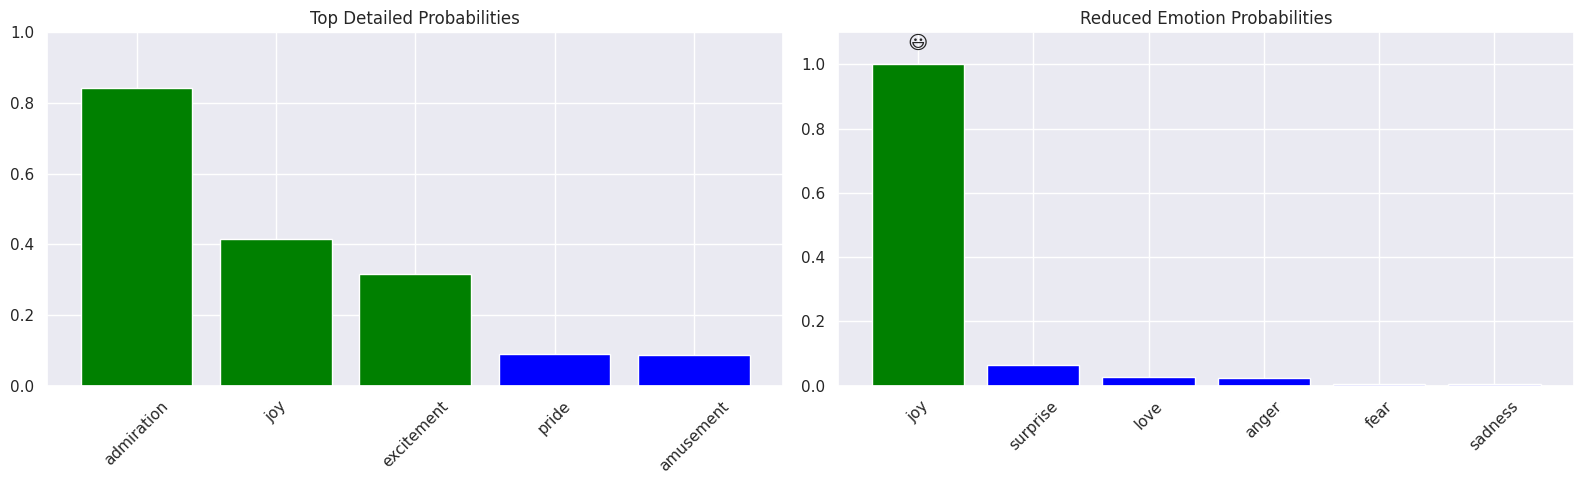


Text: This is awesome. But also r/dontdeadopeninside...

Top Detailed Predictions:
admiration: 0.841 (predicted)
joy: 0.415 (predicted)
excitement: 0.317 (predicted)
pride: 0.089
amusement: 0.085

Reduced Predictions:
joy 😃: 1.000 (predicted)
surprise 😲: 0.064
love ❤: 0.026
anger 😠: 0.025
fear 😨: 0.006
sadness 😭: 0.004

Text: 'This is a very good point, which I hadn't thought of. Thanks dull!'


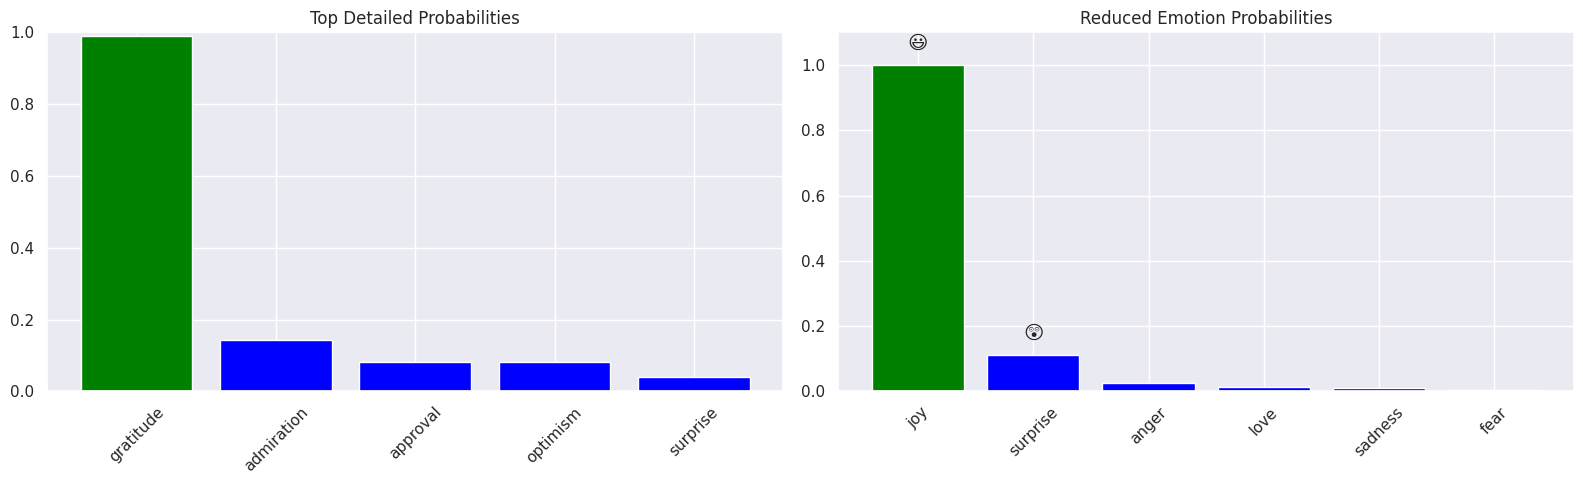


Text: This is a very good point, which I hadn't thought of. Thanks dull!...

Top Detailed Predictions:
gratitude: 0.991 (predicted)
admiration: 0.143
approval: 0.083
optimism: 0.082
surprise: 0.040

Reduced Predictions:
joy 😃: 1.000 (predicted)
surprise 😲: 0.112
anger 😠: 0.026
love ❤: 0.013
sadness 😭: 0.011
fear 😨: 0.004

Text: 'Trier is low key an awful defender'


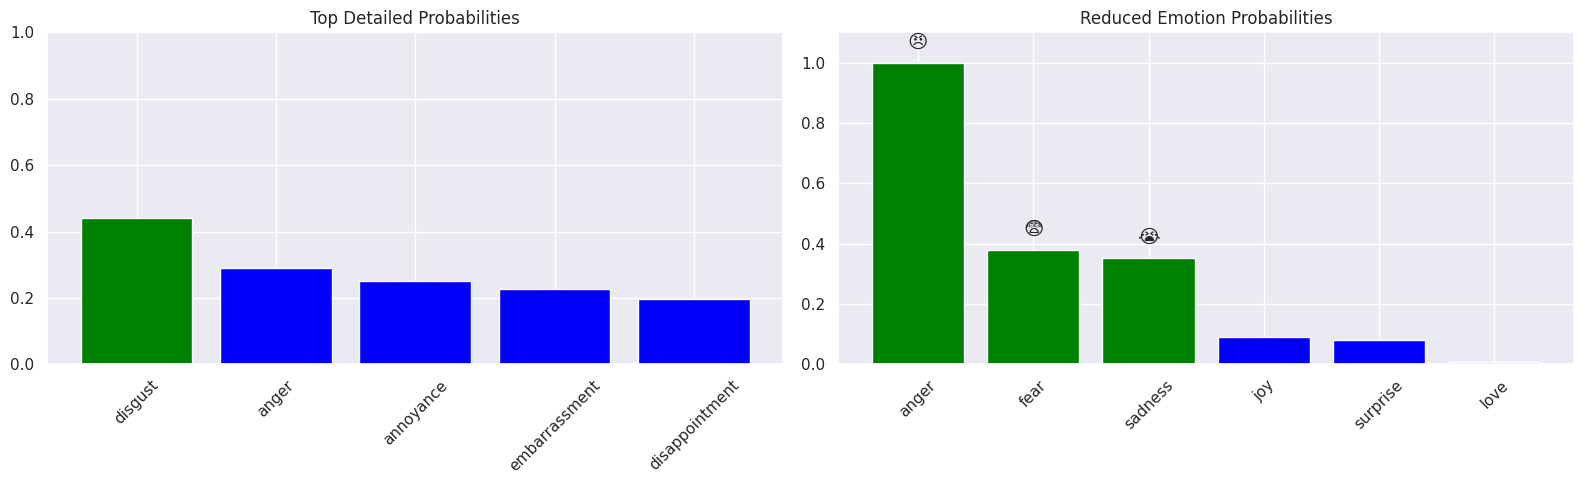


Text: Trier is low key an awful defender...

Top Detailed Predictions:
disgust: 0.440 (predicted)
anger: 0.292
annoyance: 0.251
embarrassment: 0.227
disappointment: 0.196

Reduced Predictions:
anger 😠: 1.000 (predicted)
fear 😨: 0.381 (predicted)
sadness 😭: 0.352 (predicted)
joy 😃: 0.091
surprise 😲: 0.081
love ❤: 0.007

Text: 'Sapa is pretty good, but Takashi is by far the best quality sushi in Salt Lake.'


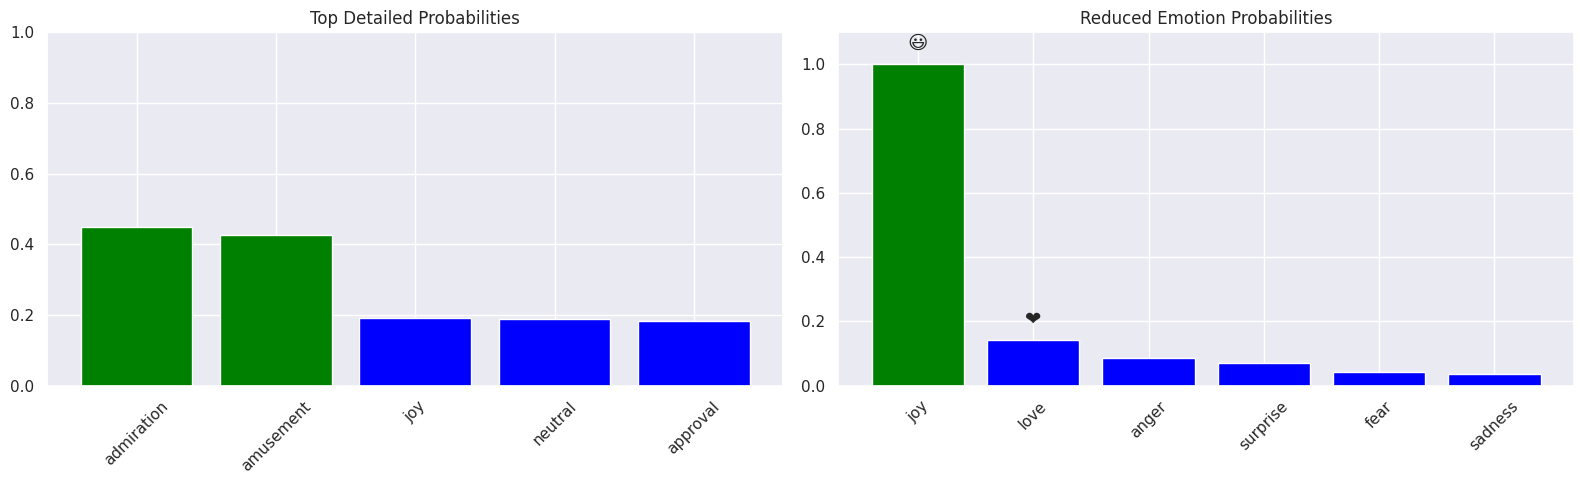


Text: Sapa is pretty good, but Takashi is by far the best quality sushi in Salt Lake....

Top Detailed Predictions:
admiration: 0.449 (predicted)
amusement: 0.428 (predicted)
joy: 0.192
neutral: 0.188
approval: 0.183

Reduced Predictions:
joy 😃: 1.000 (predicted)
love ❤: 0.141
anger 😠: 0.085
surprise 😲: 0.069
fear 😨: 0.044
sadness 😭: 0.036


In [ ]:
# Example predictions with enhanced visualization
example_texts = test_df.loc[4:7,'text'].values.tolist()

print("\nEnhanced Example Predictions:")
for text in example_texts:
    print(f"\nText: '{text}'")
    results = predict_reduced_emotions(
    text=text,
    model=model,
    tokenizer=tokenizer,
    emotion_columns=train_df.columns[2:].tolist(),
    EMOTION_MAPPING=EMOTION_MAPPING,
    threshold=0.3
)